# 手遊付費行為分析

## 專案背景
本分析針對手遊玩家的付費行為進行深入研究，
探討不同年齡層、遊戲類型、付費時機對付費金額的影響，
提供遊戲公司在行銷策略與變現模式上的建議。

## 數據說明
- 資料筆數：3,024筆
- 資料來源：Kaggle Mobile Game In-App Purchases Dataset 2025
- 分析指標：付費金額、年齡層、遊戲類型、首次付費天數

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('font', family='Microsoft JhengHei')

df = pd.read_csv('mobile_game_inapp_purchases.csv')
print(f"資料筆數：{len(df)}")
print(df.head())

資料筆數：3024
                                 UserID   Age  Gender      Country   Device  \
0  c9889ab0-9cfc-4a75-acd9-5eab1df0015c  49.0    Male       Norway  Android   
1  7c9e413c-ecca-45f2-a780-2826a07952a2  15.0    Male  Switzerland      iOS   
2  fd61e419-1a92-4f43-a8c7-135842ad328a  23.0    Male        China  Android   
3  bdb7f6d1-ff9a-468c-afe7-43f32a94293e  31.0    Male       Mexico  Android   
4  aa7eec14-4846-47b9-b879-9c98038cda04  37.0  Female        India  Android   

       GameGenre  SessionCount  AverageSessionLength SpendingSegment  \
0  Battle Royale             9                 12.83          Minnow   
1     Action RPG            11                 19.39          Minnow   
2       Fighting             9                  8.87          Minnow   
3         Racing            12                 19.56          Minnow   
4  Battle Royale            10                 15.23          Minnow   

   InAppPurchaseAmount  FirstPurchaseDaysAfterInstall PaymentMethod  \
0          

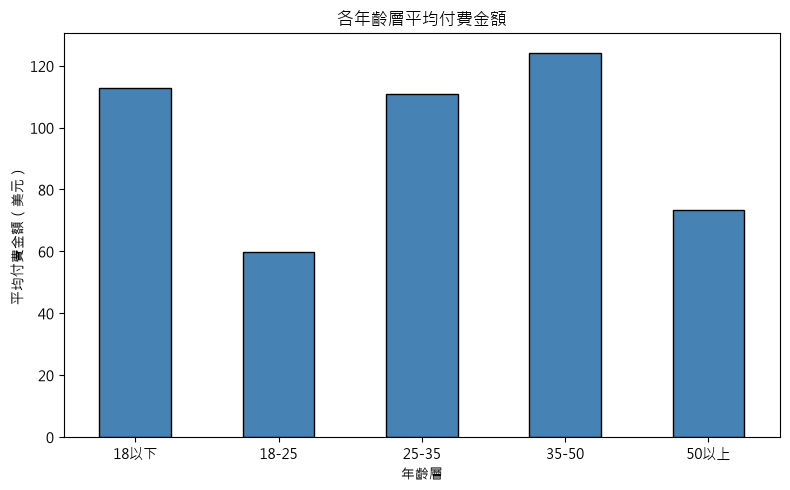

AgeGroup
18以下     112.74
18-25     59.83
25-35    111.02
35-50    124.26
50以上      73.41
Name: InAppPurchaseAmount, dtype: float64


In [3]:
# 分析一：哪種玩家最容易付費？
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 18, 25, 35, 50, 100], 
                         labels=['18以下', '18-25', '25-35', '35-50', '50以上'])
age_analysis = df.groupby('AgeGroup')['InAppPurchaseAmount'].mean().round(2)

plt.figure(figsize=(8, 5))
age_analysis.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('各年齡層平均付費金額')
plt.xlabel('年齡層')
plt.ylabel('平均付費金額（美元）')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(age_analysis)

## 分析一：哪種玩家最容易付費？

**結論：**
- 35-50歲玩家平均付費最高（$124），是最有價值的族群
- 18-25歲付費最低（$59），可能因為消費能力較弱
- 男性付費（$115）明顯高於女性（$87）

**建議：**
針對35-50歲男性玩家加強付費道具推廣，ROI最高。

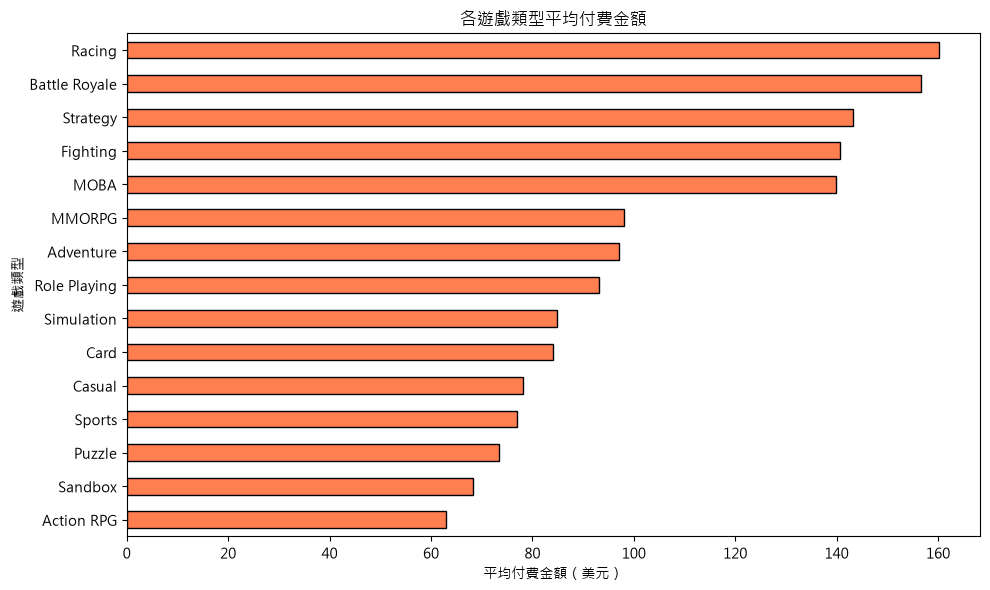

In [5]:
# 分析二：哪個遊戲類型最賺錢？
genre_analysis = df.groupby('GameGenre')['InAppPurchaseAmount'].mean().round(2).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
genre_analysis.plot(kind='barh', color='coral', edgecolor='black')
plt.title('各遊戲類型平均付費金額')
plt.xlabel('平均付費金額（美元）')
plt.ylabel('遊戲類型')
plt.tight_layout()
plt.show()

## 分析二：哪個遊戲類型最賺錢？

**結論：**
- Racing和Battle Royale付費最高（$160、$157）
- Action RPG和Sandbox墊底（$63、$68）

**建議：**
競技類遊戲適合推Battle Pass和付費道具；休閒類建議改用廣告變現。

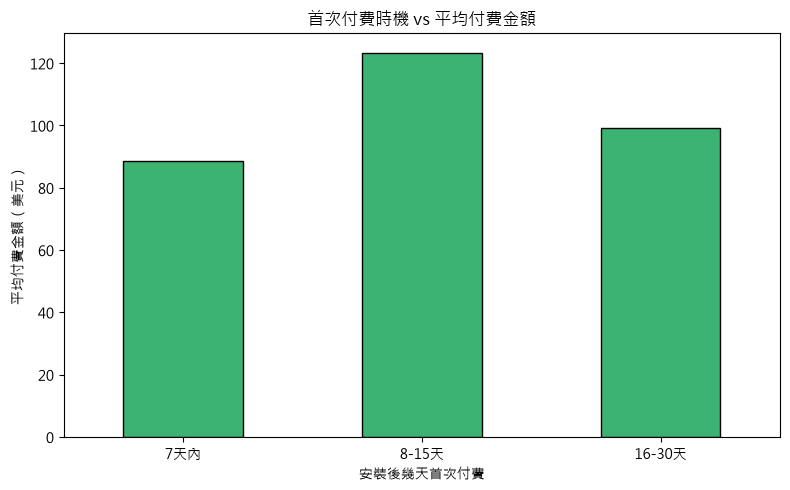

In [6]:
# 分析三：什麼時候推付費最有效？
df['PurchaseSpeed'] = pd.cut(df['FirstPurchaseDaysAfterInstall'], 
                              bins=[-1, 7, 15, 30],
                              labels=['7天內', '8-15天', '16-30天'])
speed_analysis = df.groupby('PurchaseSpeed')['InAppPurchaseAmount'].mean().round(2)

plt.figure(figsize=(8, 5))
speed_analysis.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('首次付費時機 vs 平均付費金額')
plt.xlabel('安裝後幾天首次付費')
plt.ylabel('平均付費金額（美元）')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 分析三：什麼時候推付費最有效？

**結論：**
- 8-15天首次付費的玩家平均消費最高（$123）
- 最快付費的玩家反而消費較低（$88）

**建議：**
安裝後第8-15天是推送付費優惠的黃金時機，不要急著在第一週就推。

---

## 總結
本分析從三個維度探討手遊玩家付費行為：
1. **目標族群**：35-50歲男性玩家付費意願最高
2. **遊戲類型**：Racing和Battle Royale變現潛力最大
3. **推送時機**：安裝後8-15天為黃金付費視窗

這三個洞察可直接應用於遊戲行銷策略規劃與付費道具設計。